# Hazard CONUS Grid - Hail x Solar - Hayhurst Reference Bridge

**Purpose:** compare the selected-cell grid smoke-test row for `hayhurst_reference` against the completed
deep Hayhurst hail x solar run.

This is a QA bridge, not a calibration step. The two runs should **not** match exactly:

```text
grid smoke Hayhurst-reference
  canonical 100 MW solar, 1.5 km2, 0.25 degree cell
  Apr-Jun 2024 MRMS selected-cell M1
  clipped cell-day footprint proxy
  Poisson placeholder

deep Hayhurst asset
  real 24.8 MW asset, ~0.50 km2 array, 50-mile local catalog
  2020-10-15 to 2026-06-08 MRMS record
  full event swath geometry
  fitted Negative Binomial count model
```

The bridge asks: are differences explainable, and did the grid smoke test preserve the same core interface
discipline: frequency and severity stay separate until stochastic annual-loss simulation?

## 0 - Imports and paths

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
SMOKE_VERSION = "v2026_06_16"

GRID_SOLAR_DIR = ROOT / "data" / "hazard_conus_grid" / "hail" / "solar"
GRID_METRICS_CSV = GRID_SOLAR_DIR / f"m4_solar_smoke_risk_metrics_{SMOKE_VERSION}.csv"
GRID_METADATA_JSON = GRID_SOLAR_DIR / f"m4_solar_smoke_risk_metrics_{SMOKE_VERSION}.json"

DEEP_DIR = ROOT / "data" / "hail"
DEEP_M1_JSON = DEEP_DIR / "hayhurst_hail_m1_manifest.json"
DEEP_M2_JSON = DEEP_DIR / "hayhurst_hail_m2_summary.json"
DEEP_M3_JSON = DEEP_DIR / "hayhurst_hail_m3_summary.json"
DEEP_M4_JSON = DEEP_DIR / "hayhurst_hail_m4_metrics.json"

BRIDGE_CSV = GRID_SOLAR_DIR / f"hayhurst_reference_bridge_{SMOKE_VERSION}.csv"
BRIDGE_JSON = GRID_SOLAR_DIR / f"hayhurst_reference_bridge_{SMOKE_VERSION}.json"

print(f"grid metrics: {GRID_METRICS_CSV}")
print(f"deep Hayhurst metrics: {DEEP_M4_JSON}")

grid metrics: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/solar/m4_solar_smoke_risk_metrics_v2026_06_16.csv
deep Hayhurst metrics: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hail/hayhurst_hail_m4_metrics.json


## 1 - Load the grid and deep Hayhurst summaries

In [2]:
grid_metrics = pd.read_csv(GRID_METRICS_CSV)
grid_meta = json.loads(GRID_METADATA_JSON.read_text())
deep_m1 = json.loads(DEEP_M1_JSON.read_text())
deep_m2 = json.loads(DEEP_M2_JSON.read_text())
deep_m3 = json.loads(DEEP_M3_JSON.read_text())
deep_m4 = json.loads(DEEP_M4_JSON.read_text())

grid = grid_metrics.loc[grid_metrics["role"].eq("hayhurst_reference")].iloc[0]
assert grid["cell_id"] == 336544
assert grid_meta["qa"]["all_checks_pass"] is True

display(
    pd.DataFrame(
        [
            {
                "run": "grid smoke",
                "cell_or_asset": "hayhurst_reference cell 336544",
                "capacity_mw": grid["capacity_mw"],
                "tiv_usd_m": grid["tiv_usd"] / 1e6,
                "lambda_asset": grid["lambda_asset"],
                "eal_pct_tiv": grid["eal_pct_tiv"],
                "pml100_pct_tiv": grid["pml_aep_rp100_pct_tiv"],
                "zero_loss_fraction": grid["zero_loss_fraction"],
            },
            {
                "run": "deep Hayhurst",
                "cell_or_asset": deep_m4["asset"],
                "capacity_mw": 24.8,
                "tiv_usd_m": deep_m4["tiv_usd"] / 1e6,
                "lambda_asset": deep_m4["lambda_asset_per_yr"],
                "eal_pct_tiv": deep_m4["metrics_pct_of_tiv"]["EAL"] / 100.0,
                "pml100_pct_tiv": deep_m4["metrics_pct_of_tiv"]["VaR99 (AEP-PML100)"] / 100.0,
                "zero_loss_fraction": deep_m4["zero_loss_fraction"],
            },
        ]
    )
)

print("Takeaway: the bridge compares run contexts first; metric differences are only interpretable after that.")

,run,cell_or_asset,capacity_mw,tiv_usd_m,lambda_asset,eal_pct_tiv,pml100_pct_tiv,zero_loss_fraction
0,grid smoke,hayhurst_reference cell 336544,100.0,148.3000,0.203122,0.003316,0.036671,0.81542
1,deep Hayhurst,Hayhurst Texas Solar,24.8,36.7784,0.261200,0.057000,0.543000,0.77240


Takeaway: the bridge compares run contexts first; metric differences are only interpretable after that.


## 2 - Build the comparison table

Rows are intentionally written as review notes, not just numeric diffs. The key check is whether a future
reader can see why a difference exists.

In [3]:
deep_capacity_mw = 24.8
deep_eal_usd = float(deep_m4["metrics_usd"]["EAL"])
deep_tiv_usd = float(deep_m4["tiv_usd"])
deep_eal_pct = float(deep_m4["metrics_pct_of_tiv"]["EAL"]) / 100.0
deep_pml100_pct = float(deep_m4["metrics_pct_of_tiv"]["VaR99 (AEP-PML100)"]) / 100.0
deep_oep_pml100_pct = float(deep_m4["metrics_pct_of_tiv"]["OEP-PML100"]) / 100.0
deep_tvar99_pct = float(deep_m4["metrics_pct_of_tiv"]["TVaR99"]) / 100.0
deep_eal_per_kwp = deep_eal_usd / (deep_capacity_mw * 1000.0)

grid_eal_pct = float(grid["eal_pct_tiv"])
grid_pml100_pct = float(grid["pml_aep_rp100_pct_tiv"])
grid_oep_pml100_pct = float(grid["pml_oep_rp100_pct_tiv"])
grid_tvar99_pct = float(grid["tvar_aep_99_pct_tiv"])


def money(x: float) -> str:
    if not np.isfinite(x):
        return "n/a"
    if abs(x) >= 1e6:
        return f"${x/1e6:,.2f}M"
    return f"${x:,.0f}"


def pct(x: float) -> str:
    if not np.isfinite(x):
        return "n/a"
    return f"{100*x:.2f}%"


rows = [
    {
        "group": "Purpose",
        "item": "Allowed use",
        "grid_smoke": "selected-cell interface smoke test",
        "deep_hayhurst": "completed deep asset run, real but record-limited",
        "interpretation": "Use the bridge for explainability and drift checks, not calibration.",
        "bridge_read": "pass",
    },
    {
        "group": "Exposure",
        "item": "Capacity",
        "grid_smoke": f"{grid['capacity_mw']:.1f} MW canonical solar",
        "deep_hayhurst": f"{deep_capacity_mw:.1f} MW real asset",
        "interpretation": "Dollar metrics should differ by exposure size; compare %TIV and per-kW for scale.",
        "bridge_read": "expected_difference",
    },
    {
        "group": "Exposure",
        "item": "TIV",
        "grid_smoke": money(float(grid["tiv_usd"])),
        "deep_hayhurst": money(deep_tiv_usd),
        "interpretation": "Grid dollars are on a 100 MW canonical denominator.",
        "bridge_read": "expected_difference",
    },
    {
        "group": "Exposure",
        "item": "Solar footprint",
        "grid_smoke": f"{grid['asset_area_km2']:.3f} km2 canonical footprint",
        "deep_hayhurst": f"{deep_m2['asset_footprint_km2']:.3f} km2 estimated array footprint",
        "interpretation": "The larger canonical footprint raises grid hit probability relative to the real asset.",
        "bridge_read": "expected_difference",
    },
    {
        "group": "M1",
        "item": "Hazard record",
        "grid_smoke": "MRMS Apr-Jun 2024 selected-cell window",
        "deep_hayhurst": f"{deep_m1['coverage_temporal']['start']} to {deep_m1['coverage_temporal']['end']}",
        "interpretation": "The grid row is a short-window pilot; the deep run has a multi-year local catalog.",
        "bridge_read": "expected_difference",
    },
    {
        "group": "M1",
        "item": "Event/severity sample count",
        "grid_smoke": f"{int(grid['n_smoke_event_samples'])} cell-day samples",
        "deep_hayhurst": f"{deep_m1['n_events']} event swaths",
        "interpretation": "The grid tail is visibly truncated; high-return metrics should be lower and less meaningful.",
        "bridge_read": "expected_difference",
    },
    {
        "group": "M1/M4",
        "item": "Count model",
        "grid_smoke": str(grid["freq_dist_used"]) + " placeholder",
        "deep_hayhurst": f"{deep_m4['count_model']}, Fano {deep_m4['fano_factor']}",
        "interpretation": "The deep run has over-dispersion; the grid smoke test intentionally does not.",
        "bridge_read": "expected_difference",
    },
    {
        "group": "M2",
        "item": "Coupling basis",
        "grid_smoke": "cell-clipped severe native-pixel area proxy",
        "deep_hayhurst": "full MRMS event swath geometry in a 50-mile local region",
        "interpretation": "Same areal hit-or-miss idea, different footprint object; equality is not expected.",
        "bridge_read": "expected_difference",
    },
    {
        "group": "M2",
        "item": "Mean p_hit",
        "grid_smoke": f"{float(grid['mean_p_hit']):.4f}",
        "deep_hayhurst": f"{deep_m2['mean_p_hit']:.4f}",
        "interpretation": "Grid p_hit is higher, consistent with larger canonical footprint and clipped cell-day proxy.",
        "bridge_read": "directionally_explained",
    },
    {
        "group": "Frequency",
        "item": "lambda_asset",
        "grid_smoke": f"{float(grid['lambda_asset']):.3f}/yr",
        "deep_hayhurst": f"{deep_m4['lambda_asset_per_yr']:.3f}/yr",
        "interpretation": "Same order of magnitude, but sources and bases differ; this is a bridge sanity check only.",
        "bridge_read": "directionally_reasonable",
    },
    {
        "group": "M3",
        "item": "Damage curve",
        "grid_smoke": str(grid["damage_curve_id"]),
        "deep_hayhurst": str(deep_m3["curve_id"]),
        "interpretation": "The damage curve is intentionally shared; this is the strongest interface alignment.",
        "bridge_read": "pass",
    },
    {
        "group": "M3",
        "item": "Max conditional loss",
        "grid_smoke": f"{pct(float(grid['cond_loss_max_pct_tiv']))} of TIV",
        "deep_hayhurst": f"{100*deep_m3['max_conditional_loss_usd']/deep_tiv_usd:.2f}% of TIV",
        "interpretation": "Grid Hayhurst cell saw only low/moderate MESH samples; deep run includes much larger hail.",
        "bridge_read": "expected_difference",
    },
    {
        "group": "M4",
        "item": "EAL",
        "grid_smoke": f"{money(float(grid['eal_usd']))} ({pct(grid_eal_pct)}, ${float(grid['eal_usd_per_kwp_yr']):.2f}/kWp-yr)",
        "deep_hayhurst": f"{money(deep_eal_usd)} ({pct(deep_eal_pct)}, ${deep_eal_per_kwp:.2f}/kWp-yr)",
        "interpretation": "Deep EAL is much higher because it has a longer/harsher severity sample and fitted count process.",
        "bridge_read": "expected_difference",
    },
    {
        "group": "M4",
        "item": "AEP PML100 / VaR99",
        "grid_smoke": f"{pct(grid_pml100_pct)} of TIV",
        "deep_hayhurst": f"{pct(deep_pml100_pct)} of TIV",
        "interpretation": "The grid smoke tail is truncated by only two low-severity cell-day samples.",
        "bridge_read": "expected_difference",
    },
    {
        "group": "M4",
        "item": "OEP PML100",
        "grid_smoke": f"{pct(grid_oep_pml100_pct)} of TIV",
        "deep_hayhurst": f"{pct(deep_oep_pml100_pct)} of TIV",
        "interpretation": "Same story as AEP: deep has larger swaths/intensities and fitted over-dispersion.",
        "bridge_read": "expected_difference",
    },
    {
        "group": "M4",
        "item": "TVaR99",
        "grid_smoke": f"{pct(grid_tvar99_pct)} of TIV",
        "deep_hayhurst": f"{pct(deep_tvar99_pct)} of TIV",
        "interpretation": "Grid TVaR is not meaningful as a tail estimate until M1 adds longer record and EVT/tail treatment.",
        "bridge_read": "expected_difference",
    },
    {
        "group": "M4",
        "item": "Zero-loss years",
        "grid_smoke": pct(float(grid["zero_loss_fraction"])),
        "deep_hayhurst": pct(float(deep_m4["zero_loss_fraction"])),
        "interpretation": "Both runs are in the same rare-hit regime; the absolute difference is acceptable for this bridge.",
        "bridge_read": "directionally_reasonable",
    },
]

bridge = pd.DataFrame(rows)
display(bridge)

print("Takeaway: differences are expected and documented; no row suggests the grid smoke test is calibrated to the deep run.")

,group,item,grid_smoke,deep_hayhurst,interpretation,bridge_read
0,Purpose,Allowed use,selected-cell interface smoke test,"completed deep asset run, real but record-limited",Use the bridge for explainability and drift ch...,pass
1,Exposure,Capacity,100.0 MW canonical solar,24.8 MW real asset,Dollar metrics should differ by exposure size;...,expected_difference
2,Exposure,TIV,$148.30M,$36.78M,Grid dollars are on a 100 MW canonical denomin...,expected_difference
3,Exposure,Solar footprint,1.500 km2 canonical footprint,0.502 km2 estimated array footprint,The larger canonical footprint raises grid hit...,expected_difference
4,M1,Hazard record,MRMS Apr-Jun 2024 selected-cell window,2020-10-15 to 2026-06-08,The grid row is a short-window pilot; the deep...,expected_difference
5,M1,Event/severity sample count,2 cell-day samples,158 event swaths,The grid tail is visibly truncated; high-retur...,expected_difference
6,M1/M4,Count model,poisson placeholder,"negative_binomial, Fano 3.37",The deep run has over-dispersion; the grid smo...,expected_difference
7,M2,Coupling basis,cell-clipped severe native-pixel area proxy,full MRMS event swath geometry in a 50-mile lo...,"Same areal hit-or-miss idea, different footpri...",expected_difference
8,M2,Mean p_hit,0.0253,0.0088,"Grid p_hit is higher, consistent with larger c...",directionally_explained
9,Frequency,lambda_asset,0.203/yr,0.261/yr,"Same order of magnitude, but sources and bases...",directionally_reasonable


Takeaway: differences are expected and documented; no row suggests the grid smoke test is calibrated to the deep run.


## 3 - Numeric readout of the main metric differences

,metric,grid_smoke,deep_hayhurst,grid_over_deep
0,lambda_asset_per_yr,0.203122,0.2612,0.777651
1,eal_pct_tiv,0.003316,0.0570,0.058177
2,pml_aep_rp100_pct_tiv,0.036671,0.5430,0.067534
3,oep_pml100_pct_tiv,0.018335,0.3410,0.053770
4,zero_loss_fraction,0.815420,0.7724,1.055697


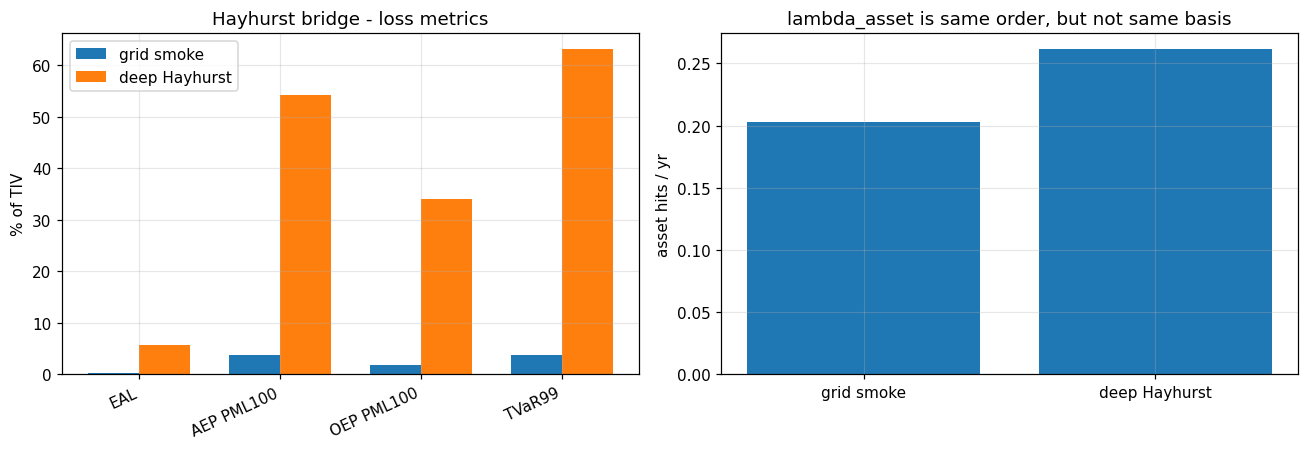

Takeaway: frequency is same order; severity/tail is not, because the grid row has only two low-severity cell-day samples.


In [4]:
numeric = pd.DataFrame(
    [
        {
            "metric": "lambda_asset_per_yr",
            "grid_smoke": float(grid["lambda_asset"]),
            "deep_hayhurst": float(deep_m4["lambda_asset_per_yr"]),
            "grid_over_deep": float(grid["lambda_asset"]) / float(deep_m4["lambda_asset_per_yr"]),
        },
        {
            "metric": "eal_pct_tiv",
            "grid_smoke": grid_eal_pct,
            "deep_hayhurst": deep_eal_pct,
            "grid_over_deep": grid_eal_pct / deep_eal_pct,
        },
        {
            "metric": "pml_aep_rp100_pct_tiv",
            "grid_smoke": grid_pml100_pct,
            "deep_hayhurst": deep_pml100_pct,
            "grid_over_deep": grid_pml100_pct / deep_pml100_pct,
        },
        {
            "metric": "oep_pml100_pct_tiv",
            "grid_smoke": grid_oep_pml100_pct,
            "deep_hayhurst": deep_oep_pml100_pct,
            "grid_over_deep": grid_oep_pml100_pct / deep_oep_pml100_pct,
        },
        {
            "metric": "zero_loss_fraction",
            "grid_smoke": float(grid["zero_loss_fraction"]),
            "deep_hayhurst": float(deep_m4["zero_loss_fraction"]),
            "grid_over_deep": float(grid["zero_loss_fraction"]) / float(deep_m4["zero_loss_fraction"]),
        },
    ]
)
display(numeric)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
metric_labels = ["EAL", "AEP PML100", "OEP PML100", "TVaR99"]
grid_vals = [grid_eal_pct, grid_pml100_pct, grid_oep_pml100_pct, grid_tvar99_pct]
deep_vals = [deep_eal_pct, deep_pml100_pct, deep_oep_pml100_pct, deep_tvar99_pct]
x = np.arange(len(metric_labels))
width = 0.36
ax[0].bar(x - width / 2, np.array(grid_vals) * 100, width, label="grid smoke")
ax[0].bar(x + width / 2, np.array(deep_vals) * 100, width, label="deep Hayhurst")
ax[0].set_xticks(x, metric_labels, rotation=25, ha="right")
ax[0].set_ylabel("% of TIV")
ax[0].set_title("Hayhurst bridge - loss metrics")
ax[0].legend()

ax[1].bar(["grid smoke", "deep Hayhurst"], [float(grid["lambda_asset"]), deep_m4["lambda_asset_per_yr"]])
ax[1].set_ylabel("asset hits / yr")
ax[1].set_title("lambda_asset is same order, but not same basis")
plt.tight_layout()
plt.show()

print("Takeaway: frequency is same order; severity/tail is not, because the grid row has only two low-severity cell-day samples.")

## 4 - Bridge verdict

A pass here means: the difference is explainable and the smoke-test interface did not drift from the deep
M2-M4 method. It does **not** mean the grid values are calibrated or ready to report.

In [5]:
bridge_status = "pass_for_interface_bridge_not_calibration"
blocking_findings: list[str] = []
watchlist = [
    "Grid Hayhurst has only two hail-day samples and no high-severity tail.",
    "Grid uses Poisson placeholder; deep Hayhurst uses fitted Negative Binomial with Fano 3.37.",
    "Grid coupling footprint is clipped severe area inside the cell, not full connected storm swath.",
    "Grid metrics remain selected-cell smoke-test outputs and are not reportable.",
]

if float(grid["lambda_asset"]) <= 0:
    blocking_findings.append("Grid Hayhurst lambda_asset is zero; bridge would not be meaningful.")
if str(grid["damage_curve_id"]) != str(deep_m3["curve_id"]):
    blocking_findings.append("Damage curve differs between grid and deep runs.")
if not bool(grid["qa_checks_pass"]):
    blocking_findings.append("Grid smoke-test QA checks did not pass.")

if blocking_findings:
    bridge_status = "blocked"

verdict = {
    "artifact": BRIDGE_CSV.name,
    "status": bridge_status,
    "allowed_use": "explain grid-vs-deep Hayhurst differences and check interface drift",
    "not_allowed_use": "not calibration; not final hail risk; not evidence that grid metrics are reportable",
    "grid_smoke_hayhurst": {
        "cell_id": int(grid["cell_id"]),
        "capacity_mw": float(grid["capacity_mw"]),
        "tiv_usd": float(grid["tiv_usd"]),
        "lambda_asset": float(grid["lambda_asset"]),
        "eal_pct_tiv": grid_eal_pct,
        "pml_aep_rp100_pct_tiv": grid_pml100_pct,
        "zero_loss_fraction": float(grid["zero_loss_fraction"]),
        "metrics_status": str(grid["metrics_status"]),
    },
    "deep_hayhurst": {
        "capacity_mw": deep_capacity_mw,
        "tiv_usd": deep_tiv_usd,
        "lambda_asset": float(deep_m4["lambda_asset_per_yr"]),
        "eal_pct_tiv": deep_eal_pct,
        "pml_aep_rp100_pct_tiv": deep_pml100_pct,
        "zero_loss_fraction": float(deep_m4["zero_loss_fraction"]),
        "metrics_status": str(deep_m4["metrics_status"]),
    },
    "blocking_findings": blocking_findings,
    "watchlist": watchlist,
    "inputs": {
        "grid_metrics": str(GRID_METRICS_CSV.relative_to(ROOT)),
        "deep_m1": str(DEEP_M1_JSON.relative_to(ROOT)),
        "deep_m2": str(DEEP_M2_JSON.relative_to(ROOT)),
        "deep_m3": str(DEEP_M3_JSON.relative_to(ROOT)),
        "deep_m4": str(DEEP_M4_JSON.relative_to(ROOT)),
    },
    "outputs": {
        "bridge_csv": str(BRIDGE_CSV.relative_to(ROOT)),
        "bridge_json": str(BRIDGE_JSON.relative_to(ROOT)),
    },
}

print(json.dumps({k: verdict[k] for k in ["status", "blocking_findings", "watchlist"]}, indent=2))

{
  "status": "pass_for_interface_bridge_not_calibration",
  "blocking_findings": [],
  "watchlist": [
    "Grid Hayhurst has only two hail-day samples and no high-severity tail.",
    "Grid uses Poisson placeholder; deep Hayhurst uses fitted Negative Binomial with Fano 3.37.",
    "Grid coupling footprint is clipped severe area inside the cell, not full connected storm swath.",
    "Grid metrics remain selected-cell smoke-test outputs and are not reportable."
  ]
}


## 5 - Persist bridge artifacts

In [6]:
bridge.to_csv(BRIDGE_CSV, index=False)
BRIDGE_JSON.write_text(json.dumps(verdict, indent=2))

print(f"wrote bridge CSV: {BRIDGE_CSV}")
print(f"wrote bridge JSON: {BRIDGE_JSON}")

wrote bridge CSV: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/solar/hayhurst_reference_bridge_v2026_06_16.csv
wrote bridge JSON: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling/data/hazard_conus_grid/hail/solar/hayhurst_reference_bridge_v2026_06_16.json


## Findings

- The bridge passes as an **interface/drift check**: the damage curve is shared, grid QA checks passed, and
  the key differences are explainable from exposure, record window, footprint basis, count model, and
  severity sample size.
- It does **not** pass as calibration, because that is not the task. The grid smoke row has only two
  low-severity hail-day samples and a Poisson placeholder.
- The deep Hayhurst run is much higher in EAL and tail metrics because it has a longer MRMS event catalog,
  larger observed hail sizes, full event swath geometry, and a fitted over-dispersed count process.
- Next modeling work should improve M1 before treating grid risk values as meaningful: longer-record
  MYRORSS/MRMS support, MESH de-biasing, sparse-cell pooling, and EVT/tail treatment.